# 256. Paint House
https://leetcode.com/problems/paint-house/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| DP with extra array | O(n) | O(n) | Store min cost for each house/color |
| **DP in-place (Optimal)** | **O(n)** | **O(1)** | Modify costs array in place |

## Methodology

Dynamic programming where for each house, we compute the minimum cost of painting it each color by adding the current color cost to the minimum of the other two colors from the previous house. We can do this in-place by modifying the input array. The answer is the minimum of the three costs for the last house.

## Solutions

### C#

In [ ]:
public class Solution {
    public int MinCost(int[][] costs) {
        int n = costs.Length;
        if (n == 0) return 0;
        for (int i = 1; i < n; i++) {
            costs[i][0] += Math.Min(costs[i-1][1], costs[i-1][2]);
            costs[i][1] += Math.Min(costs[i-1][0], costs[i-1][2]);
            costs[i][2] += Math.Min(costs[i-1][0], costs[i-1][1]);
        }
        return Math.Min(costs[n-1][0], Math.Min(costs[n-1][1], costs[n-1][2]));
    }
}

### Python

In [ ]:
class Solution:
    def minCost(self, costs: list[list[int]]) -> int:
        if not costs:
            return 0
        for i in range(1, len(costs)):
            costs[i][0] += min(costs[i-1][1], costs[i-1][2])
            costs[i][1] += min(costs[i-1][0], costs[i-1][2])
            costs[i][2] += min(costs[i-1][0], costs[i-1][1])
        return min(costs[-1])

### Go

In [ ]:
func minCost(costs [][]int) int {
    n := len(costs)
    if n == 0 {
        return 0
    }
    for i := 1; i < n; i++ {
        costs[i][0] += min(costs[i-1][1], costs[i-1][2])
        costs[i][1] += min(costs[i-1][0], costs[i-1][2])
        costs[i][2] += min(costs[i-1][0], costs[i-1][1])
    }
    return min(costs[n-1][0], min(costs[n-1][1], costs[n-1][2]))
}

### Rust

In [ ]:
impl Solution {
    pub fn min_cost(mut costs: Vec<Vec<i32>>) -> i32 {
        let n = costs.len();
        if n == 0 { return 0; }
        for i in 1..n {
            let (a, b, c) = (costs[i-1][0], costs[i-1][1], costs[i-1][2]);
            costs[i][0] += b.min(c);
            costs[i][1] += a.min(c);
            costs[i][2] += a.min(b);
        }
        *costs[n-1].iter().min().unwrap()
    }
}

## Example Scenarios

1. **Common Case** — `costs = [[17,2,17],[16,16,5],[14,3,19]]`
   **Input:** A $3 \times 3$ cost matrix for 3 houses.
   House 0 picks green (cost 2), house 1 picks blue (cost 5), house 2 picks green (cost 3). Total = $2+5+3=10$.

2. **Slightly Complex** — `costs = [[5,8,6],[19,14,13],[7,5,12],[14,15,17],[3,20,10]]`
   **Input:** 5 houses with varying costs.
   The DP propagates minimum costs forward ensuring no two adjacent houses share a color; the optimal path yields a total of $43$.

3. **Edge Case: Time Factor** — `costs = [[1,100,100],[100,1,100],[1,100,100],...]` for $n=10^4$ houses
   **Input:** $10{,}000$ houses alternating cheap colors.
   The $O(n)$ single-pass DP handles this in one sweep — each row does 3 additions and 2 comparisons, so even $10^4$ rows finish instantly.

4. **Edge Case: Space Factor** — `costs = [[7,6,2]]`
   **Input:** A single house (minimum valid input).
   Only one row means no DP iteration; just return $\min(7,6,2)=2$. In-place DP uses $O(1)$ extra space.

5. **Almost-Impossible but Plausible** — `costs = [[1,2,3],[4,5,6],[7,8,9],...,[2998,2999,3000]]` with $n=1000$
   **Input:** 1000 houses with costs $1$ to $3000$ in sequence.
   Despite uniformly rising costs, the DP must still carefully alternate colors; the greedy choice at each step is not always globally optimal, making this a good stress test for correctness.

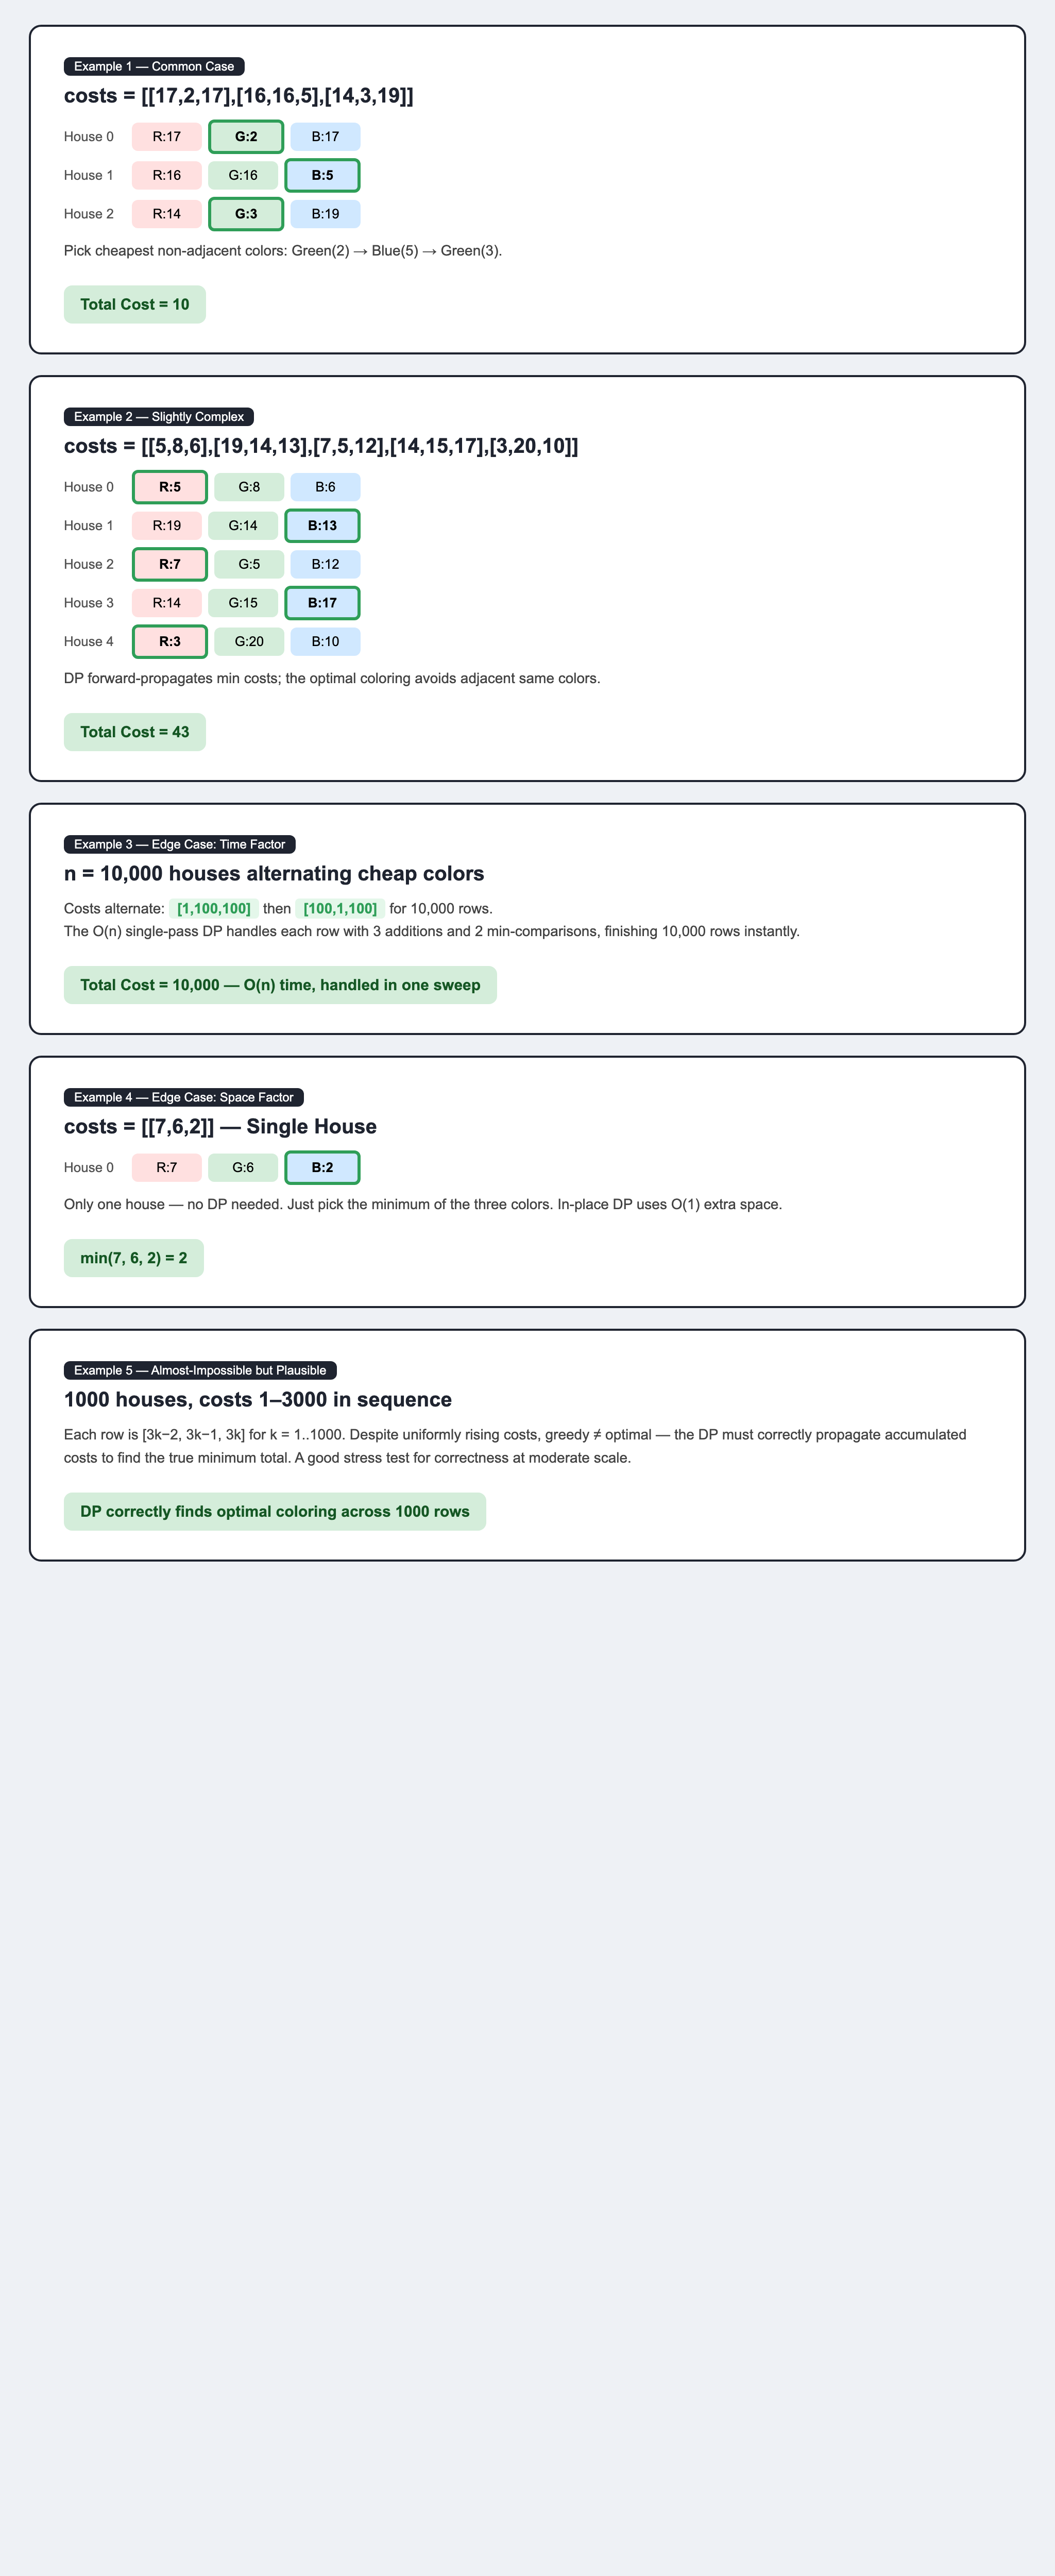